<a href="https://colab.research.google.com/github/gninassi/Industrial-Engineering-Projects/blob/main/Supply_Chain_Optimization_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pulp
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


Status: Optimal
Total Logistics Cost: $20,600.00



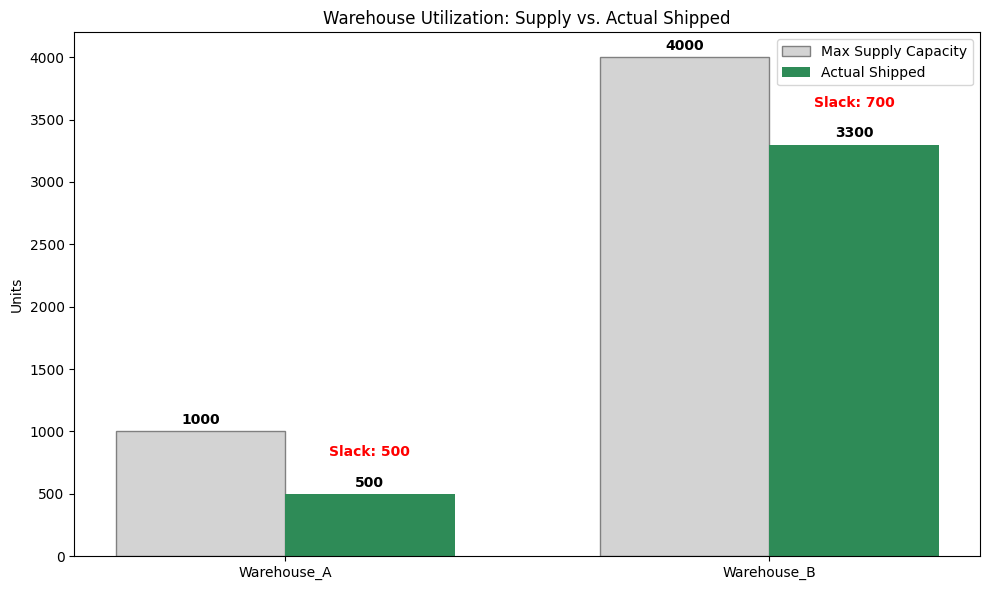

In [ ]:
# 1. Initialize the Model
model = pulp.LpProblem("Supply_Chain_Optimization", pulp.LpMinimize)

# 2. Define Data
warehouses = ["Warehouse_A", "Warehouse_B"]
stores = ["Store_1", "Store_2", "Store_3"]

supply = {"Warehouse_A": 1000, "Warehouse_B": 4000}
demand = {"Store_1": 500, "Store_2": 1500, "Store_3": 1800}

costs = {
    "Warehouse_A": {"Store_1": 4, "Store_2": 6, "Store_3": 9},
    "Warehouse_B": {"Store_1": 5, "Store_2": 4, "Store_3": 7}
}

# 3. Define Variables
routes = [(w, s) for w in warehouses for s in stores]
vars = pulp.LpVariable.dicts("Route", (warehouses, stores), lowBound=0, cat='Integer')

# 4. Objective Function: Minimize Total Logistics Cost
model += pulp.lpSum([vars[w][s] * costs[w][s] for (w, s) in routes])

# 5. Constraints
# Supply constraints for each warehouse
for w in warehouses:
    model += pulp.lpSum([vars[w][s] for s in stores]) <= supply[w], f"Supply_Limit_{w}"

# Demand constraints for each store
for s in stores:
    model += pulp.lpSum([vars[w][s] for w in warehouses]) >= demand[s], f"Demand_Requirement_{s}"

# 6. Solve the Model
model.solve()

# 7. Print Text Results
print(f"Status: {pulp.LpStatus[model.status]}")
print(f"Total Logistics Cost: ${pulp.value(model.objective):,.2f}\n")

# 8. Data Preparation for Visualization
# Calculate actual quantities shipped and current slack
shipment_results = {w: sum(vars[w][s].varValue for s in stores) for w in warehouses}
labels = warehouses
max_supply = [supply[w] for w in warehouses]
actual_shipped = [shipment_results[w] for w in warehouses]
slack = [supply[w] - shipment_results[w] for w in warehouses]

# 9. Create Visualization: Supply vs. Actual Shipped
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, max_supply, width, label='Max Supply Capacity', color='#D3D3D3', edgecolor='gray')
rects2 = ax.bar(x + width/2, actual_shipped, width, label='Actual Shipped', color='#2E8B57')

ax.set_ylabel('Units')
ax.set_title('Warehouse Utilization: Supply vs. Actual Shipped')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Annotate the Slack (Unused Capacity)
for i in range(len(labels)):
    # Position text slightly above the 'Actual Shipped' bar
    ax.text(i + width/2, actual_shipped[i] + 300, f'Slack: {int(slack[i])}',
            ha='center', color='red', fontweight='bold')

plt.tight_layout()
plt.show()



